# Visualising RK-PINN solutions

This notebook trains a Runge–Kutta PINN on the 1D heat equation and looks at what it
learned: the loss history, the solution as it evolves, where the error concentrates,
and an interactive sweep over time.

The problem is

$$u_t - u_{xx} = 0 \quad\text{on } (0,1)\times(0,T], \qquad u(0,t)=u(1,t)=0, \qquad u(x,0)=\sin(\pi x),$$

whose exact solution is $u(x,t) = \sin(\pi x)\,e^{-\pi^2 t}$. Having a closed form is
the point — every plot below is measured against truth rather than eyeballed.

**Runtime:** roughly 1–2 minutes on CPU.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import torch

from pinn_rk import (
    MLP,
    Laplacian1D,
    RkPinnConfig,
    RkPinnLoss,
    TimeMesh,
    butcher_radau_iia_q2,
)

%matplotlib inline
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cpu | device: cpu


## The problem

`Phi(x) = x(1-x)` multiplies the network output, so the homogeneous Dirichlet
conditions hold *exactly* by construction — boundary error never enters the loss and
never has to be traded off against anything else.

In [2]:
T = 0.1  # final time
N = 8  # time slabs
N_X = 96  # spatial samples per slab
STEPS = 400
LR = 5e-3


def exact_u(x, t):
    return torch.sin(math.pi * x) * torch.exp(-(math.pi**2) * t)


def zero_rhs(x, t):
    return torch.zeros_like(x)


# Initial data, sampled on a sorted grid (required by the H1 penalty).
x0 = torch.linspace(1e-6, 1 - 1e-6, 128, device=device).unsqueeze(1)
u0 = exact_u(x0, torch.zeros_like(x0))

mesh = TimeMesh.uniform(T=T, N=N, device=device)
model = MLP(width=96, depth=4, dtype=torch.float64).to(device)

cfg = RkPinnConfig(
    tableau=butcher_radau_iia_q2(device),
    time_mesh=mesh,
    residual="rk",  # full Butcher tableau: stage + update equations
    n_x_train=N_X,
    device=device,
    init_data=(x0, u0),
)
loss_fn = RkPinnLoss(model=model, Lop=Laplacian1D(), f_rhs=zero_rhs, cfg=cfg).to(device)
print(f"{sum(p.numel() for p in model.parameters()):,} trainable parameters")

28,321 trainable parameters


## Training

The loss is stochastic: `spatial_sampler` redraws the collocation points every step, so
the trace is noisy by design. That is worth seeing rather than smoothing away — a
single noisy loss value says very little about progress.

In [3]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
history = []

t0 = time.perf_counter()
for step in range(1, STEPS + 1):
    opt.zero_grad(set_to_none=True)
    loss = loss_fn()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()
    history.append(loss.item())
    if step % 100 == 0:
        print(f"[{step:4d}] loss = {loss.item():.4e}")
print(f"\ntrained in {time.perf_counter() - t0:.1f}s")

[ 100] loss = 1.2710e-01


[ 200] loss = 5.8559e-02


[ 300] loss = 1.4999e-02


[ 400] loss = 1.2170e-02

trained in 117.7s


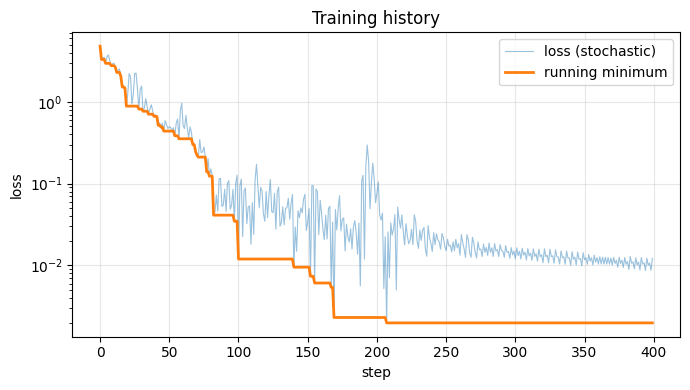

In [4]:
def running_min(xs):
    out, best = [], float("inf")
    for v in xs:
        best = min(best, v)
        out.append(best)
    return out


fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history, lw=0.8, alpha=0.45, label="loss (stochastic)")
ax.semilogy(running_min(history), lw=2.0, label="running minimum")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Training history")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Solution evolution

The initial condition decays by $e^{-\pi^2 T}\approx 0.37$ over $T=0.1$. Dashed lines
are the exact solution.

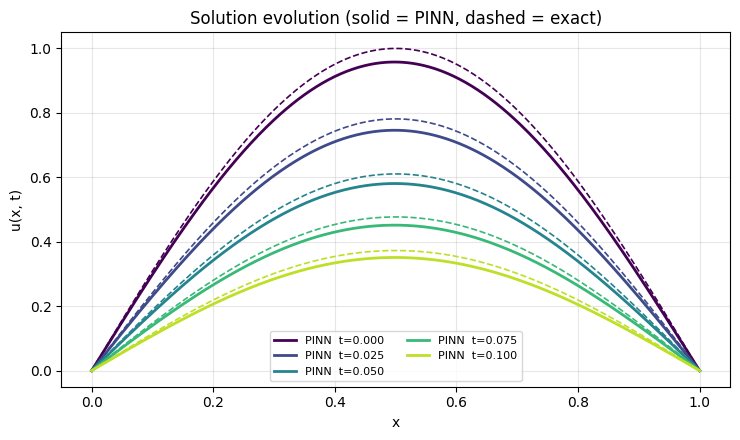

In [5]:
xs = torch.linspace(0, 1, 401, device=device).unsqueeze(1)
times = torch.linspace(0, T, 5)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = plt.cm.viridis(torch.linspace(0, 0.9, len(times)).numpy())
for tv, col in zip(times, colors, strict=True):
    tt = torch.full_like(xs, float(tv))
    with torch.no_grad():
        pred = model(xs, tt)
    ax.plot(xs.cpu(), pred.cpu(), color=col, lw=2, label=f"PINN  t={float(tv):.3f}")
    ax.plot(xs.cpu(), exact_u(xs, tt).cpu(), color=col, lw=1.2, ls="--")

ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.set_title("Solution evolution (solid = PINN, dashed = exact)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Where the error lives

A single L2 number hides the structure. The heat map shows $|u_\theta - u|$ across the
whole space-time domain, and the right panel tracks how the error grows with time.

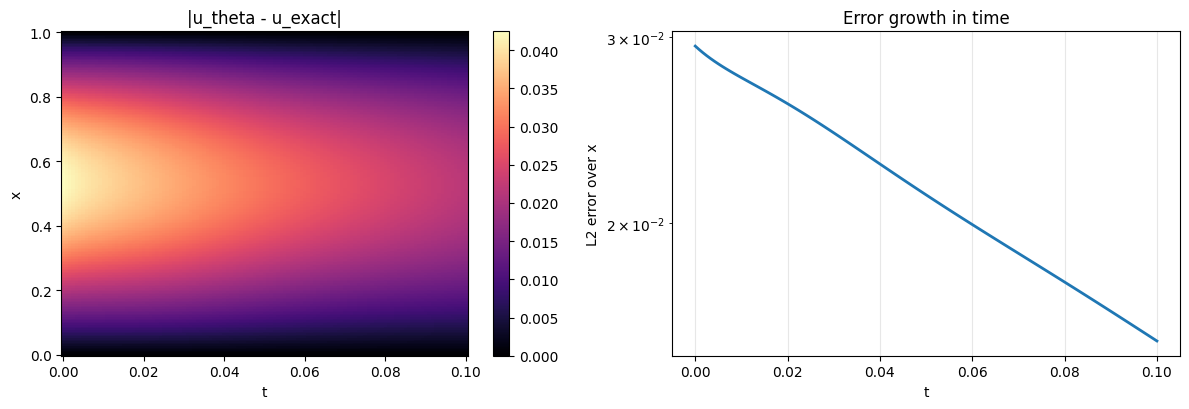

L2 error at t=0    : 2.9395e-02
L2 error at t=0.10 : 1.5460e-02
max abs error      : 4.2474e-02


In [6]:
nx, nt = 201, 121
gx = torch.linspace(0, 1, nx, device=device)
gt = torch.linspace(0, T, nt, device=device)
XX, TT = torch.meshgrid(gx, gt, indexing="ij")
flat_x, flat_t = XX.reshape(-1, 1), TT.reshape(-1, 1)

with torch.no_grad():
    pred = model(flat_x, flat_t)
err = (pred - exact_u(flat_x, flat_t)).abs().reshape(nx, nt).cpu()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
im = a1.pcolormesh(gt.cpu(), gx.cpu(), err, shading="auto", cmap="magma")
a1.set_xlabel("t")
a1.set_ylabel("x")
a1.set_title("|u_theta - u_exact|")
fig.colorbar(im, ax=a1)

l2_t = err.pow(2).mean(dim=0).sqrt()
a2.semilogy(gt.cpu(), l2_t, lw=2)
a2.set_xlabel("t")
a2.set_ylabel("L2 error over x")
a2.set_title("Error growth in time")
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"L2 error at t=0    : {l2_t[0]:.4e}")
print(f"L2 error at t={T:.2f} : {l2_t[-1]:.4e}")
print(f"max abs error      : {err.max():.4e}")

The absolute error actually *shrinks* with time here, but that is the solution
shrinking rather than the approximation improving. The exact solution decays by
$e^{-\pi^2 T} \approx 0.37$ over this interval, so constant relative accuracy shows up as
a falling absolute error. Dividing through by $\lVert u(\cdot,t)\rVert$ shows the
*relative* error growing instead, which is the honest reading: nothing anchors the
late-time solution except the Runge-Kutta relations propagating information forward
from $t=0$.

Note also that the initial-condition penalty is an $H^1$ *seminorm*. It matches
$\partial_x u$ against $\partial_x u_0$, not the values themselves, so it does not pin
$u(\cdot,0)$ pointwise. That is why $t=0$ is not automatically the most accurate slice.

## Interactive exploration

A slider over time, using Plotly.

> GitHub's notebook viewer does not execute JavaScript, so this figure appears blank
> on github.com. Run the notebook locally to use it.

In [7]:
import plotly.graph_objects as go

sl_x = torch.linspace(0, 1, 201, device=device).unsqueeze(1)
frames, slider_steps = [], []
tvals = torch.linspace(0, T, 21)

for i, tv in enumerate(tvals):
    tt = torch.full_like(sl_x, float(tv))
    with torch.no_grad():
        p = model(sl_x, tt).squeeze(1).cpu()
    e = exact_u(sl_x, tt).squeeze(1).cpu()
    frames.append(go.Frame(data=[go.Scatter(y=p), go.Scatter(y=e)], name=f"{i}"))
    slider_steps.append(
        dict(method="animate", label=f"{float(tv):.3f}", args=[[f"{i}"], dict(mode="immediate")])
    )

x_axis = sl_x.squeeze(1).cpu()
fig = go.Figure(
    data=[
        go.Scatter(x=x_axis, y=frames[0].data[0].y, name="PINN", line=dict(width=3)),
        go.Scatter(x=x_axis, y=frames[0].data[1].y, name="exact", line=dict(width=2, dash="dash")),
    ],
    frames=frames,
)
fig.update_layout(
    title="u(x, t) over time",
    xaxis_title="x",
    yaxis_title="u",
    yaxis_range=[-0.05, 1.05],
    height=460,
    sliders=[dict(active=0, currentvalue=dict(prefix="t = "), steps=slider_steps)],
)
fig.show()

## Comparing the two residual forms

`residual` selects what the loss actually imposes. `"rk"` uses the full Butcher tableau;
`"interpolant"` differentiates a polynomial reconstruction and ignores the coupling
matrix `A`. They are genuinely different objectives, so it is worth looking at both.

Note that the consistency advantage of `"rk"` — see the README — bounds what a
*perfectly trained* network could reach. It does not predict which one a given short
optimisation run will favour, and in practice they trade places.

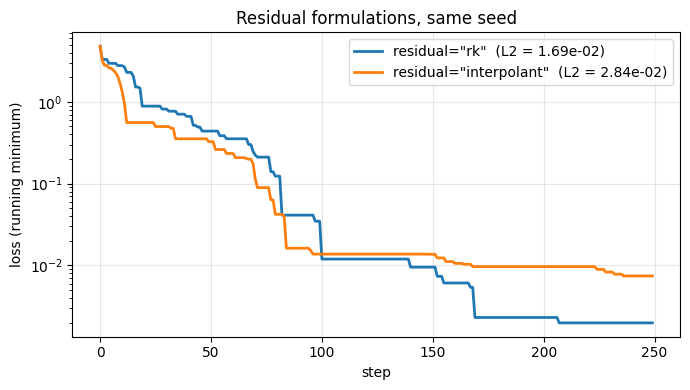

rk           final L2 = 1.6857e-02
interpolant  final L2 = 2.8413e-02


In [8]:
def train(residual, steps=250, seed=0):
    torch.manual_seed(seed)
    m = MLP(width=96, depth=4, dtype=torch.float64).to(device)
    cfg_ = RkPinnConfig(
        tableau=butcher_radau_iia_q2(device),
        time_mesh=TimeMesh.uniform(T=T, N=N, device=device),
        residual=residual,
        n_x_train=N_X,
        device=device,
        init_data=(x0, u0),
    )
    fn = RkPinnLoss(model=m, Lop=Laplacian1D(), f_rhs=zero_rhs, cfg=cfg_).to(device)
    o = torch.optim.Adam(m.parameters(), lr=LR)
    hist = []
    for _ in range(steps):
        o.zero_grad(set_to_none=True)
        ls = fn()
        ls.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
        o.step()
        hist.append(ls.item())
    xg = torch.linspace(0, 1, 401, device=device).unsqueeze(1)
    tg = torch.full_like(xg, T)
    with torch.no_grad():
        l2 = (m(xg, tg) - exact_u(xg, tg)).pow(2).mean().sqrt().item()
    return hist, l2


runs = {r: train(r) for r in ("rk", "interpolant")}

fig, ax = plt.subplots(figsize=(7, 4))
for name, (hist, l2) in runs.items():
    ax.semilogy(running_min(hist), lw=2, label=f'residual="{name}"  (L2 = {l2:.2e})')
ax.set_xlabel("step")
ax.set_ylabel("loss (running minimum)")
ax.set_title("Residual formulations, same seed")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for name, (_, l2) in runs.items():
    print(f"{name:12} final L2 = {l2:.4e}")

**A caution on reading that plot.** This is one seed, one budget, one problem. The
loss values are not comparable across formulations either — the two objectives are
different quantities, so only the L2 error against the exact solution is a fair
comparison. Drawing a general conclusion would need several seeds and converged runs;
see the note in the project README.

## Where to go next

- `benchmarking.ipynb` — cost, scaling, and the accuracy each tableau buys per unit of work
- Switch `butcher_radau_iia_q2` for `butcher_gauss_legendre_q2`: same two stages, classical order 4 instead of 3
- Set `ic_weight` on `RkPinnConfig` to rebalance the initial-condition penalty against the PDE residual